In [1]:
import os
import numpy as np
import re
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [2]:
import re
class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        self.text = text
        self.n = n
        self.alpha = alpha
        self.ngrams = {}
        self.probabilities = {}
        self.vocab = set()
        self.sentences = []
        self.context_counts = {}
        self.total = 0

    def tokenize(self):
        text = self.text.lower()

        # The corpus already marks sentences with <s> ... </s>, so split on </s>
        parts = text.split('</s>')

        self.sentences = []
        tokens = []
        for part in parts:
            part = part.replace('<s>', '')
            # Keep letters, digits, and apostrophes (handles atlanta's, o'clock)
            words = re.findall(r"[a-z0-9']+", part)
            # Drop tokens that are only apostrophes (the '' quote marker)
            words = [w for w in words if any(c.isalnum() for c in w)]
            if len(words) == 0:
                continue
            sent = ['<s>'] + words + ['</s>']
            self.sentences.append(sent)
            tokens.extend(sent)

        self.vocab = set(t for t in tokens if t != '<s>' and t != '</s>')
        return tokens

    def generate_ngrams(self, tokens):
        # Sliding window inside each sentence so n-grams never cross sentence boundaries
        result = []
        for sent in self.sentences:
            if len(sent) < self.n:
                continue
            for i in range(len(sent) - self.n + 1):
                result.append(tuple(sent[i:i + self.n]))
        self.ngrams = result
        return result

    def count_frequencies(self):
        counts = defaultdict(int)
        for ng in self.ngrams:
            counts[ng] += 1
        self.ngrams = dict(counts)

    def calculate_probabilities(self):
        self.probabilities = {}
        V = len(self.vocab)
        a = self.alpha

        if self.n == 1:
            # Unigram: P(w) = (count(w) + a) / (total + a * V)
            total = sum(self.ngrams.values())
            self.total = total
            for ng, c in self.ngrams.items():
                self.probabilities[ng] = (c + a) / (total + a * V)
        else:
            # Higher-order: P(w_n | prefix) = (count + a) / (prefix_count + a * V)
            contexts = defaultdict(int)
            for ng, c in self.ngrams.items():
                contexts[ng[:-1]] += c
            self.context_counts = dict(contexts)
            for ng, c in self.ngrams.items():
                prefix = ng[:-1]
                self.probabilities[ng] = (c + a) / (contexts[prefix] + a * V)

    def most_frequent_ngrams(self, top_n=10):
        sorted_ngrams = sorted(self.ngrams.items(), key=lambda x: x[1], reverse=True)
        top = sorted_ngrams[:top_n]
        return [(ng, self.probabilities[ng]) for ng, c in top]


# Quick sanity check on a tiny sentence
demo = NGramModel('This is a simple example to demonstrate how n-grams work.', 2)
t = demo.tokenize()
demo.generate_ngrams(t)
demo.count_frequencies()
demo.calculate_probabilities()
print(demo.most_frequent_ngrams(5))

[(('<s>', 'this'), 1.0), (('this', 'is'), 1.0), (('is', 'a'), 1.0), (('a', 'simple'), 1.0), (('simple', 'example'), 1.0)]


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [3]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'unigrams')

### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [4]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')

### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [5]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')

### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [6]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')

### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [7]:
def generate_text(model, n, prompt, max_length=50, seed=42):
    rng = random.Random(seed)

    # Group candidates by their context so lookups are fast
    by_context = defaultdict(list)
    for ng, p in model.probabilities.items():
        by_context[ng[:-1]].append((ng[-1], p))

    tokens = prompt.lower().split()
    if len(tokens) == 0:
        tokens = ['<s>']

    while len(tokens) < max_length:
        context = tuple(tokens[-(n - 1):]) if n > 1 else ()
        candidates = by_context.get(context, [])
        if len(candidates) == 0:
            break

        # Weighted random sampling (not argmax, otherwise the output gets stuck in a loop)
        words = [w for w, _ in candidates]
        weights = [p for _, p in candidates]
        next_word = rng.choices(words, weights=weights, k=1)[0]
        if next_word == '</s>':
            break
        tokens.append(next_word)

    return ' '.join(tokens)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

In [8]:
# Since we already have a working ngram model, for the next part we can use the ngrams to calculate the co-occurences.
model = NGramModel(corpus, 2)
tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)

def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    co_matrix = np.zeros((vocab_size, vocab_size)) #create matrix
    for i in range(len(ngrams)):
        row = word_to_index[ngrams[i][0]]
        col = word_to_index[ngrams[i][1]]
        co_matrix[row][col] += 1 
    return co_matrix

vocab = list(set(tokens))
vocab_size = len(vocab)

# Create a word-to-index mapping
word_to_index = {word: idx for idx, word in enumerate(vocab)}

# Generate the co-occurrence matrix
co_matrix = create_co_matrix(ngrams, vocab_size, word_to_index)

# Optionally, print the matrix or parts of it
#had to change .value_counts() to just print because .value_counts() is a pandas method
#print(co_matrix.value_counts())
print(co_matrix) #printed only zeros
print(co_matrix.shape)
print(f"\nTotal nonzero = {np.count_nonzero(co_matrix)} in {co_matrix.size} total matrix values")


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(809, 809)

Total nonzero = 1793 in 654481 total matrix values


With the code below you can verify if the co-occurence works

In [9]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return

    index1 = word_to_index[word1]
    index2 = word_to_index[word2]

    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")

check_co_occurrence('the', 'jury', co_matrix, word_to_index)
check_co_occurrence('the', 'cat', co_matrix, word_to_index)

#note: check co-occurrences of word pairs relevant to your corpora, commenting why these pairs are interesting

model_bigram = NGramModel(corpus, 2)
tokens_b = model_bigram.tokenize()
model_bigram.generate_ngrams(tokens_b)
model_bigram.count_frequencies()
model_bigram.calculate_probabilities()
for g, prob in model_bigram.most_frequent_ngrams(10):
    print(g, "-", int(model_bigram.ngrams[g]))

check_co_occurrence('<s>', 'the', co_matrix, word_to_index)
check_co_occurrence('in', 'the', co_matrix, word_to_index)
check_co_occurrence('of', 'the', co_matrix, word_to_index)

Co-occurrence count for 'the' and 'jury': 13.0
One or both words 'the' and 'cat' are not in the vocabulary.
('<s>', 'the') - 27
('in', 'the') - 16
('of', 'the') - 14
('the', 'jury') - 13
('jury', 'said') - 8
('the', 'fulton') - 6
('fulton', 'county') - 6
('the', 'election') - 6
('<s>', 'it') - 6
('at', 'the') - 6
Co-occurrence count for '<s>' and 'the': 27.0
Co-occurrence count for 'in' and 'the': 16.0
Co-occurrence count for 'of' and 'the': 14.0


In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [10]:
from numpy.linalg import svd

def reduce_to_k_dim(M, k=2):
    U, S, Vt = svd(M, full_matrices=False) #full_matrices=false returns matrices without wasted padding
    M_reduced = U[:, :k] *S[:k]
    #maybe try scaling by S -> that should make it more accurate?
    return M_reduced

M_reduced = reduce_to_k_dim(co_matrix, k=2)
print(M_reduced)

[[-4.48037271e-02 -2.31918484e-03]
 [-2.94618922e-03 -3.74170357e-04]
 [-1.34508217e-04 -2.85893446e-06]
 ...
 [ 0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00]
 [-4.97394509e-03  1.72179002e-03]]


In [11]:
from collections import Counter
freq = Counter(tokens)
freq.most_common(50)

[('the', 156),
 ('<s>', 100),
 ('</s>', 100),
 ('of', 67),
 ('to', 55),
 ('a', 54),
 ('in', 40),
 ('and', 40),
 ('that', 28),
 ('said', 24),
 ('for', 22),
 ('be', 21),
 ('it', 19),
 ('jury', 18),
 ('was', 18),
 ('county', 15),
 ('fulton', 14),
 ('election', 14),
 ('will', 14),
 ('which', 13),
 ('as', 13),
 ('is', 12),
 ('state', 12),
 ('his', 12),
 ('there', 11),
 ('by', 10),
 ('on', 10),
 ('has', 10),
 ('city', 9),
 ('this', 9),
 ('department', 9),
 ('at', 9),
 ('would', 9),
 ('resolution', 9),
 ('funds', 8),
 ('been', 7),
 ('he', 7),
 ('highway', 7),
 ('an', 6),
 ('these', 6),
 ('should', 6),
 ('with', 6),
 ('some', 6),
 ('new', 6),
 ('million', 6),
 ('not', 6),
 ('who', 6),
 ('rural', 6),
 ('bonds', 6),
 ('atlanta', 5)]

In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.







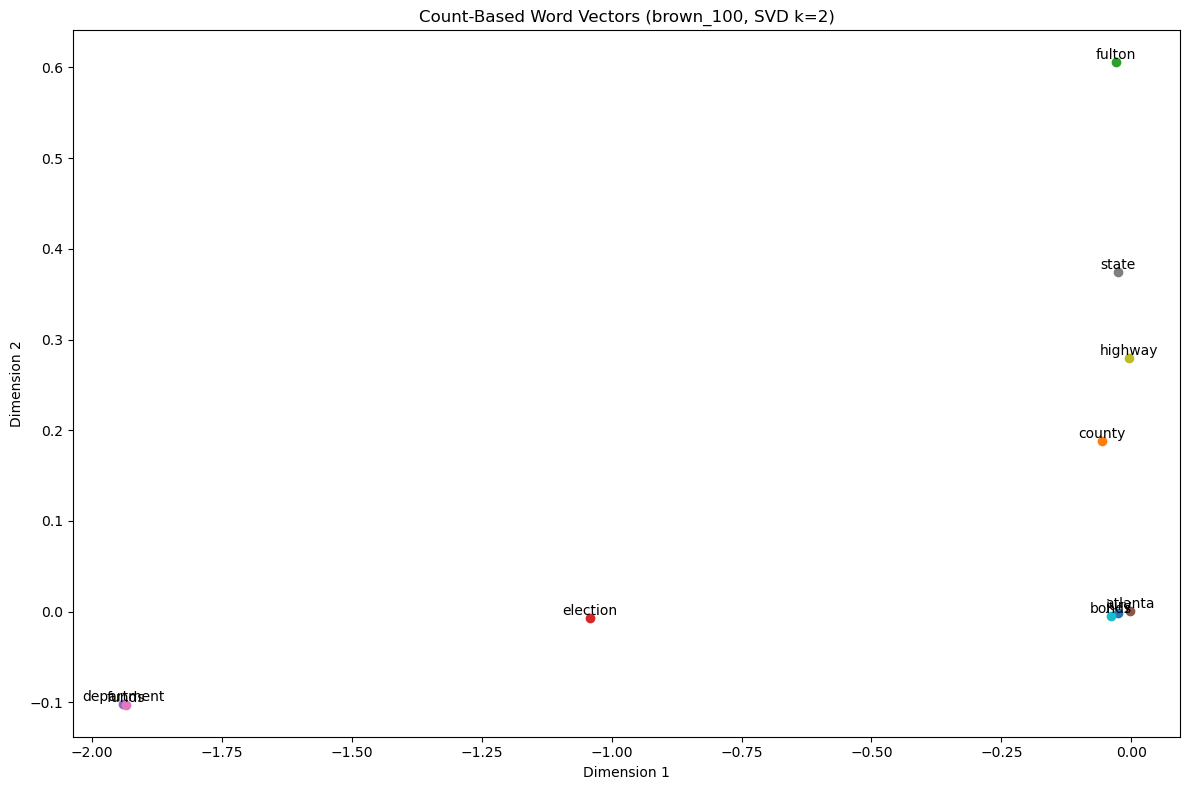

In [12]:
def plot_embeddings(M_reduced, words, word_to_index):
    plt.figure(figsize=(12,8))
    for i in words:
        ind = word_to_index[i]
        x,y = M_reduced[ind]
        plt.scatter(x,y)
        plt.annotate(i, (x,y), fontsize=10, ha='center', va='bottom')
    plt.title('Count-Based Word Vectors (brown_100, SVD k=2)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.tight_layout()
    plt.show()

#words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']
wordsBr = ['jury', 'county', 'fulton', 'election', 'department', 'atlanta', 'funds', 'state', 'highway', 'bonds']

#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do
# to decide the word list I printed the 50 most common words in the corpus but I purposefully only picked words with context, skipping function words

#plot_embeddings(M_reduced, vocab)
#had to change function call to include word_to_index
plot_embeddings(M_reduced, wordsBr, word_to_index)

## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [13]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

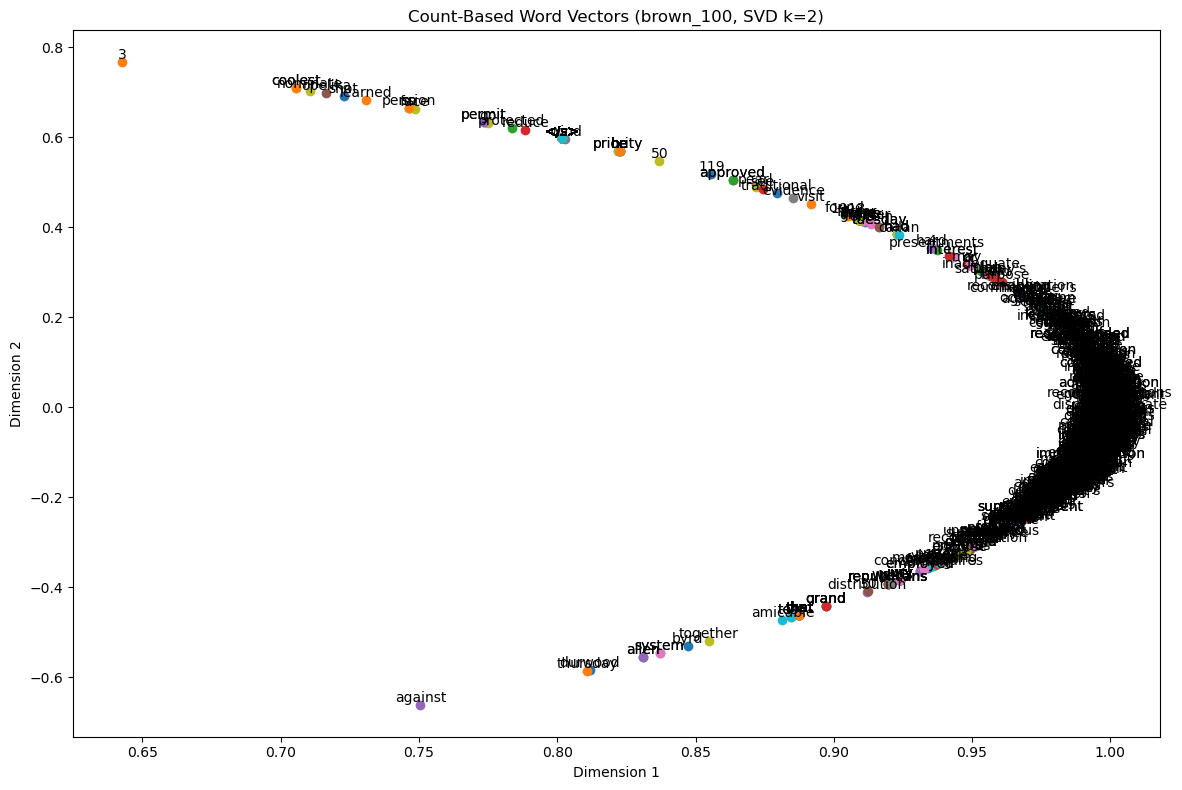

In [15]:
plot_embeddings(M_reduced_normalized, tokens, word_to_index)

### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [ ]:
## Your code here

### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.







In [ ]:
## Your code here

### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [ ]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005682587623596), ('father', 0.6659887433052063), ('aunt', 0.6623408794403076), ('grandson', 0.6618767976760864), ('grandparents', 0.644661009311676), ('wife', 0.6445354223251343)]


### Bias in word vectors
a. **Observation**: Consider the results of a word vector model when queried with analogies involving "man", "woman", and "profession". What are the top results returned by the model for each query?

[Your Answer]

b. **Analysis**: Do you observe any gender biases in the results? For example, are certain professions more closely associated with "man" or "woman" based on the word vectors? Discuss how word embeddings might perpetuate societal biases present in the training data.

[Your Answer]

c. **Reflection**: How might such biases affect the fairness of machine learning models that use word embeddings? Suggest potential strategies for mitigating gender bias in word vector models.

[Your Answer]

In [ ]:
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))